In [173]:
import sqlite3
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

In [174]:
def getting_data_Tn(limit_day):
    """
    Retrieves data from the 'rfm_table' in the SQLite database up to a specified date.

    Parameters:
    ----------
    limit_day : str
        The cutoff date in the format "YYYY:MM:DD" to filter the data.

    Returns:
    --------
    data : pandas.DataFrame
        The filtered and cleaned dataset.
    """
    
    # Conversion en objet datetime
    date_obj = datetime.strptime(limit_day, "%Y:%m:%d")

    # Conversion en Julian Day pour SQLite
    julian_day = date_obj.toordinal() + 1721424.5
    
    con = sqlite3.connect("olist.db")
    sql = pd.read_sql_query(f"Select * from rfm_table", con)
    data = pd.DataFrame(sql)
    data = data.loc[data["order_purchase_timestamp"] <= julian_day,]
    data = data.drop_duplicates()
    
    return data

In [184]:
def transform_data(data):
    """
    Transforms the data for it to be processed later

    Args:
        data pandas Dataframe: the collected data
        
    Returns:
        the transformed data
    """
    
    agg = data.groupby("customer_unique_id").agg(
     frequency=pd.NamedAgg(column="order_id", aggfunc="count"),
     recency=pd.NamedAgg(column="order_purchase_timestamp", aggfunc="max"),
     monetary=pd.NamedAgg(column="price", aggfunc="sum"),
     contentment=pd.NamedAgg(column="review_score", aggfunc="mean")
)
    
    agg["recency"] = round(data["order_purchase_timestamp"].max() - agg["recency"])
    
    agg.loc[agg["contentment"].isna(), "contentment"] = agg["contentment"].median()
    
    agg["monetary"] = np.log(agg["monetary"])
    
    agg["recency_for_sampling"] = agg["recency"]
    
    # gestion des outliers
    #agg = agg.loc[agg["frequency"] <= 5, ] # outliers fréquence
    
    mean=agg["monetary"].mean() # outliers monetary
    std=agg["monetary"].std()
    # agg = agg.loc[agg["monetary"] > mean - 3*std,]
    # agg = agg.loc[agg["monetary"] < mean + 3*std,]
    
    
    scaler = StandardScaler()
    agg[["monetary", "recency", "contentment"]] = scaler.fit_transform(agg[["monetary", "recency", "contentment"]])

    r_scaler = RobustScaler()
    agg["frequency"] = r_scaler.fit_transform(agg[["frequency"]])

    return agg

Entrainer un modèle de référence

In [176]:
def train_model(date = "2017:12:31"):
    """
    Trains a KMeans model on customer data, based on frequency, recency, monetary, and contentment features.

    Parameters:
    ----------
    date : str, optional
        The cutoff date in the format "YYYY:MM:DD" to retrieve the data (default is "2017:12:31").

    Returns:
    --------
    model : KMeans
        The trained KMeans model.
    labels : ndarray
        The cluster labels assigned to the data points.
    data : pandas.DataFrame
        The transformed data used for training the model.
    """
    
    data = getting_data_Tn(date)
    data= transform_data(data)

    data = data[["frequency", "recency", "monetary", "contentment"]] # 

    model = KMeans(n_clusters=4, random_state=0)
    
    model =model.fit(data)
    labels = model.predict(data)
    return model, labels, data

In [177]:
def generate_dates(start_date: str, end_date: str, step: int = 3):
    """
    Generates a list of dates between a start and end date, with a specified step in days.

    Parameters:
    ----------
    start_date : str
        The starting date in the format "YYYY:MM:DD".
    end_date : str
        The ending date in the format "YYYY:MM:DD".
    step : int, optional
        The number of days between each generated date (default is 3).

    Returns:
    --------
    dates : list of str
        A list of dates in the format "YYYY:MM:DD" from start to end, with the specified step.
    """
    
    start = datetime.strptime(start_date, "%Y:%m:%d")
    end = datetime.strptime(end_date, "%Y:%m:%d")
    
    current = start
    dates = []
    while current <= end:
        dates.append(current.strftime("%Y:%m:%d"))
        current += timedelta(days=step)
    
    return dates

In [178]:
def test_for_maintenance(date_list):
    """
    Tests model stability over time by calculating the Adjusted Rand Index (ARI) between
    the initial model and models trained on different dates.

    Parameters:
    ----------
    date_list : list of str
        A list of dates in the format "YYYY:MM:DD" to test model performance over time.

    Returns:
    --------
    None
        The function displays a plot showing the ARI scores over the given date range.
    """
    
    model_t0, label, data_t0 = train_model(date_list[0])
    ari_scores =  []
    for date in date_list:
        model_tn, label_tn, data_tn = train_model(date)
        predictions = model_t0.predict(data_tn)
        ari = adjusted_rand_score(label_tn, predictions)
        ari_scores.append(ari)

    sns.lineplot(x=date_list, y=ari_scores)
    plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
    plt.show()

In [179]:
sns.set()

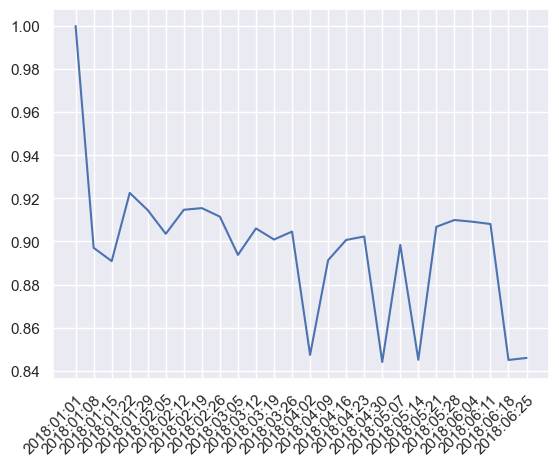

In [183]:
start_date = "2018:01:01"
end_date = "2018:06:28"
date_list = generate_dates(start_date, end_date, step=7)
test_for_maintenance(date_list)

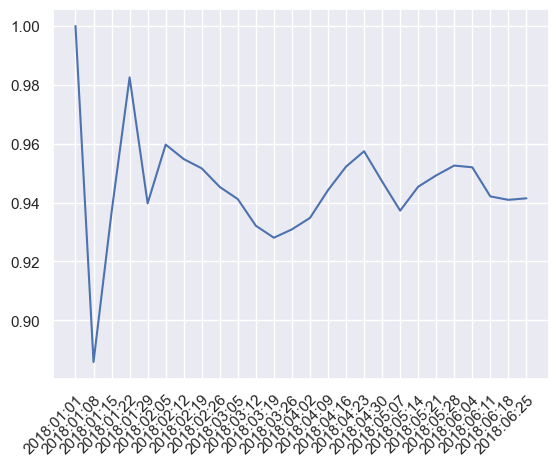

In [185]:
start_date = "2018:01:01"
end_date = "2018:06:28"
date_list = generate_dates(start_date, end_date, step=7)
test_for_maintenance(date_list)